# CSCI 261.03: Social Network Analysis 

1) Network structure & properties
2) Centrality measures
3) Network models (ER/BA/WS)
4) Edge formation mechanisms & link prediction heuristics
5) Diffusion simulation
6) Temporal SNA


## 0. Environment Setup

Run the cell below to install dependencies (if needed). If your environment already has these, you may skip.

In [2]:
# Optional: Uncomment to install
%pip install networkx matplotlib numpy pandas vaderSentiment
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import io
from collections import defaultdict
np.random.seed(42)
print('networkx:', nx.__version__)
print('numpy:', np.__version__)
print('pandas:', pd.__version__)


ERROR: Could not find a version that satisfies the requirement networkx (from versions: none)
ERROR: No matching distribution found for networkx
Note: you may need to restart the kernel to use updated packages.


ModuleNotFoundError: No module named 'networkx'

# Part 1 — Network Structure & Properties

We start with a small directed graph similar to the toy example in the slides.

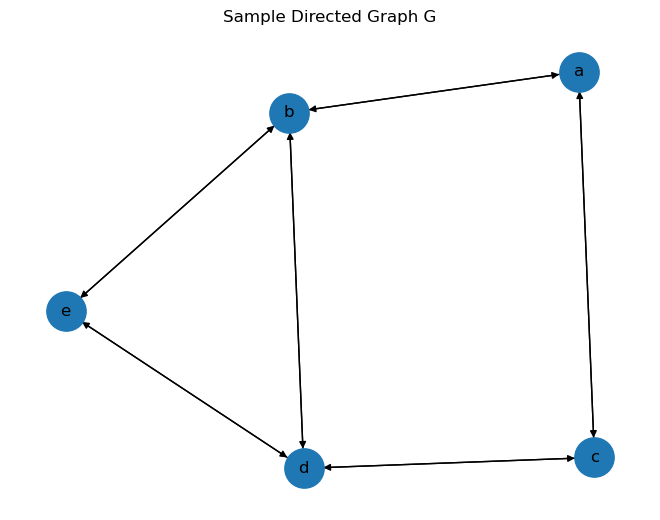

In [ ]:
# Construct sample directed graph G (a,b,c,d,e)
G = nx.DiGraph()
G.add_nodes_from(list('abcde'))
edges = [('a','c'),('a','b'),('b','a'),('b','d'),('b','e'),('c','a'),('c','d'),('d','b'),('d','c'),('d','e'),('e','b'),('e','d')]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=1)
plt.figure()
nx.draw(G, pos, with_labels=True, node_size=800)
plt.title('Sample Directed Graph G')
plt.show()


## 1. Adjacency Representations

### 1.1 Adjacency Matrix

In [ ]:
nodes = list(G.nodes())
A = nx.to_numpy_array(G, nodelist=nodes, dtype=int)
adj_df = pd.DataFrame(A, index=nodes, columns=nodes)
adj_df

,a,b,c,d,e
a,0,1,1,0,0
b,1,0,0,1,1
c,1,0,0,1,0
d,0,1,1,0,1
e,0,1,0,1,0


### 1.2 Adjacency List & Edge List

In [ ]:
# Adjacency List (dict of neighbors)
adj_list = {n: list(G.successors(n)) for n in G.nodes()}
adj_list


{'a': ['c', 'b'],
 'b': ['a', 'd', 'e'],
 'c': ['a', 'd'],
 'd': ['b', 'c', 'e'],
 'e': ['b', 'd']}

In [ ]:
# Edge List
edge_list = list(G.edges())
edge_list


[('a', 'c'),
 ('a', 'b'),
 ('b', 'a'),
 ('b', 'd'),
 ('b', 'e'),
 ('c', 'a'),
 ('c', 'd'),
 ('d', 'b'),
 ('d', 'c'),
 ('d', 'e'),
 ('e', 'b'),
 ('e', 'd')]

## 2. Network Properties

- Density (for directed graphs: m / (n*(n-1)))
- Degree / in-degree / out-degree
- (Weakly) Connected components (for directed graphs)
- Shortest path distance
- Clustering coefficient


In [ ]:
n = G.number_of_nodes()
m = G.number_of_edges()
density = m / (n*(n-1))
deg_in = dict(G.in_degree())
deg_out = dict(G.out_degree())
components = [c for c in nx.weakly_connected_components(G)]
sample_distance = nx.shortest_path_length(G, source='a', target='b')
clust_coeff = nx.clustering(G.to_undirected())  
summary = {
    'n_nodes': n,
    'n_edges': m,
    'density': density,
    'in_degree': deg_in,
    'out_degree': deg_out,
    'n_weak_components': len(components),
    'shortest_distance_a_to_b': sample_distance,
}
summary, clust_coeff


({'n_nodes': 5,
  'n_edges': 12,
  'density': 0.6,
  'in_degree': {'a': 2, 'b': 3, 'c': 2, 'd': 3, 'e': 2},
  'out_degree': {'a': 2, 'b': 3, 'c': 2, 'd': 3, 'e': 2},
  'n_weak_components': 1,
  'shortest_distance_a_to_b': 1},
 {'a': 0, 'b': 0.3333333333333333, 'c': 0, 'd': 0.3333333333333333, 'e': 1.0})

# Part 2 — Centrality Measures

Compute degree, betweenness, closeness, and eigenvector centrality, then rank top nodes.

In [ ]:
deg_cent = nx.degree_centrality(G.to_undirected())
bet_cent = nx.betweenness_centrality(G.to_undirected(), normalized=True)
clo_cent = nx.closeness_centrality(G.to_undirected())
eig_cent = nx.eigenvector_centrality(G.to_undirected(), max_iter=1000)
cent_df = pd.DataFrame({
    'degree': deg_cent,
    'betweenness': bet_cent,
    'closeness': clo_cent,
    'eigenvector': eig_cent,
}).sort_values('degree', ascending=False)
cent_df


,degree,betweenness,closeness,eigenvector
b,0.75,0.250000,0.800000,0.529899
d,0.75,0.250000,0.800000,0.529899
a,0.50,0.083333,0.666667,0.357752
c,0.50,0.083333,0.666667,0.357752
e,0.50,0.000000,0.666667,0.427132


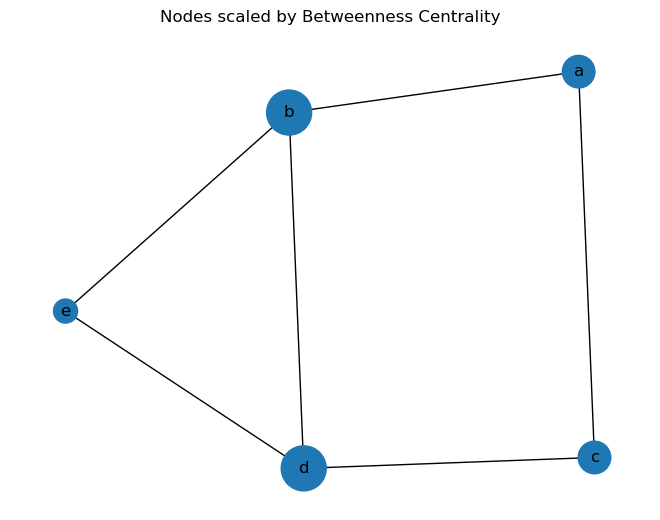

In [ ]:
# Visualize with node size scaled by betweenness centrality
plt.figure()
sizes = [3000*bet_cent[n] + 300 for n in G.nodes()]  # avoid zero size
nx.draw(G.to_undirected(), pos, with_labels=True, node_size=sizes)
plt.title('Nodes scaled by Betweenness Centrality')
plt.show()


### Example: Zachary's Karate Club (undirected)
A classic benchmark graph shipped in `networkx`.

In [ ]:
K = nx.karate_club_graph()
kpos = nx.spring_layout(K, seed=0)
k_deg = nx.degree_centrality(K)
k_bet = nx.betweenness_centrality(K)
k_clo = nx.closeness_centrality(K)
k_eig = nx.eigenvector_centrality(K, max_iter=1000)
k_df = pd.DataFrame({
    'degree': k_deg,
    'betweenness': k_bet,
    'closeness': k_clo,
    'eigenvector': k_eig,
}).sort_values('degree', ascending=False)
k_df.head(10)


,degree,betweenness,closeness,eigenvector
33,0.515152,0.304075,0.550000,0.373371
0,0.484848,0.437635,0.568966,0.355483
32,0.363636,0.145247,0.515625,0.308651
2,0.303030,0.143657,0.559322,0.317189
1,0.272727,0.053937,0.485294,0.265954
3,0.181818,0.011909,0.464789,0.211174
31,0.181818,0.138276,0.540984,0.191036
23,0.151515,0.017614,0.392857,0.150123
8,0.151515,0.055927,0.515625,0.227405
13,0.151515,0.045863,0.515625,0.226470


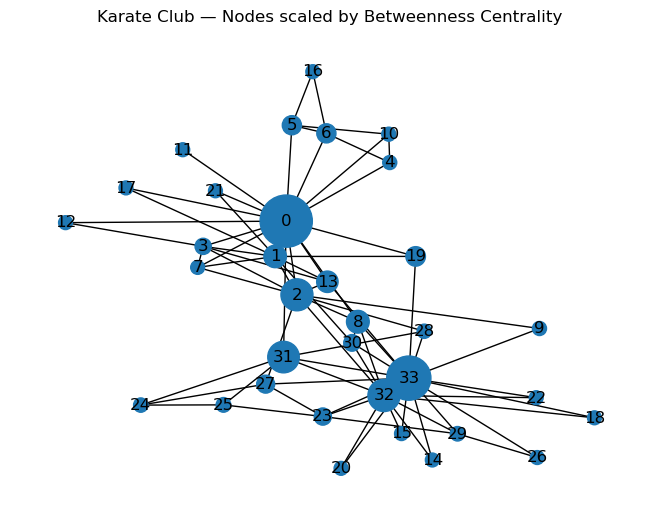

In [ ]:
plt.figure()
sizes = [3000*k_bet[n] + 100 for n in K.nodes()]
nx.draw(K, kpos, with_labels=True, node_size=sizes)
plt.title("Karate Club — Nodes scaled by Betweenness Centrality")
plt.show()


# Part 3 — Network Models (ER, BA, WS)
Generate and compare the structural properties of three canonical models.

In [ ]:
def model_graphs(n=100, p=0.05, m_attach=2, k=4, beta=0.1):
    ER = nx.erdos_renyi_graph(n, p, seed=1)
    BA = nx.barabasi_albert_graph(n, m_attach, seed=1)
    WS = nx.watts_strogatz_graph(n, k, beta, seed=1)
    return ER, BA, WS

def summarize_graph(Gu):
    n = Gu.number_of_nodes()
    m = Gu.number_of_edges()
    dens = (2*m)/(n*(n-1)) if n>1 else 0.0
    cc = nx.average_clustering(Gu)
    avg_len = np.nan
    if nx.is_connected(Gu):
        avg_len = nx.average_shortest_path_length(Gu)
    return {'n': n, 'm': m, 'density': dens, 'avg_clustering': cc, 'avg_shortest_path': avg_len}

ER, BA, WS = model_graphs()
summary_models = pd.DataFrame({
    'ER': summarize_graph(ER),
    'BA': summarize_graph(BA),
    'WS': summarize_graph(WS)
}).T
summary_models


,n,m,density,avg_clustering,avg_shortest_path
ER,100.0,267.0,0.053939,0.067092,2.911919
BA,100.0,196.0,0.039596,0.111532,3.051111
WS,100.0,200.0,0.040404,0.387667,5.066465


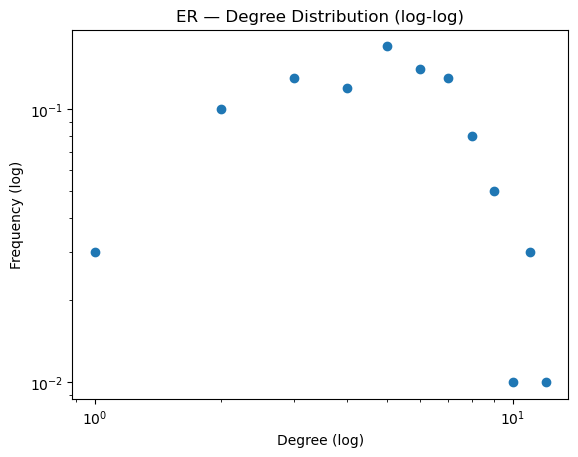

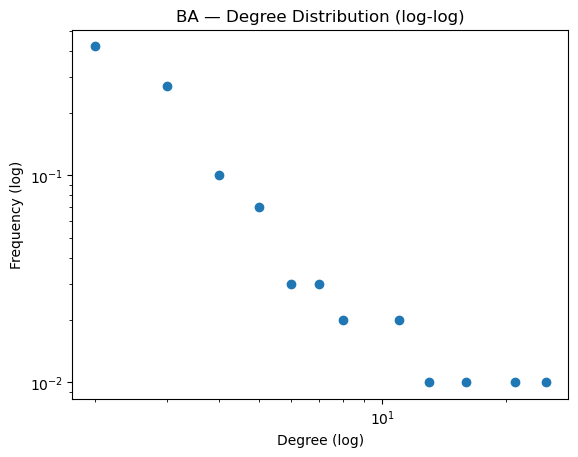

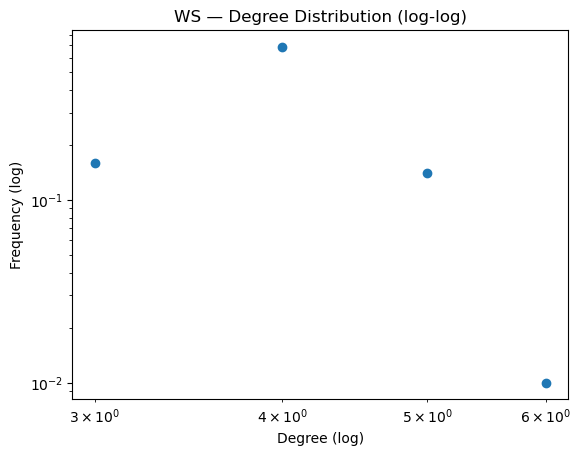

In [ ]:
# Degree distributions
def degree_hist(G):
    degs = [d for _, d in G.degree()]
    vals, counts = np.unique(degs, return_counts=True)
    return vals, counts / counts.sum()

figures = []
for name, graph in [('ER', ER), ('BA', BA), ('WS', WS)]:
    vals, freq = degree_hist(graph)
    plt.figure()
    plt.scatter(vals, freq)
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('Degree (log)')
    plt.ylabel('Frequency (log)')
    plt.title(f'{name} — Degree Distribution (log-log)')
    plt.show()


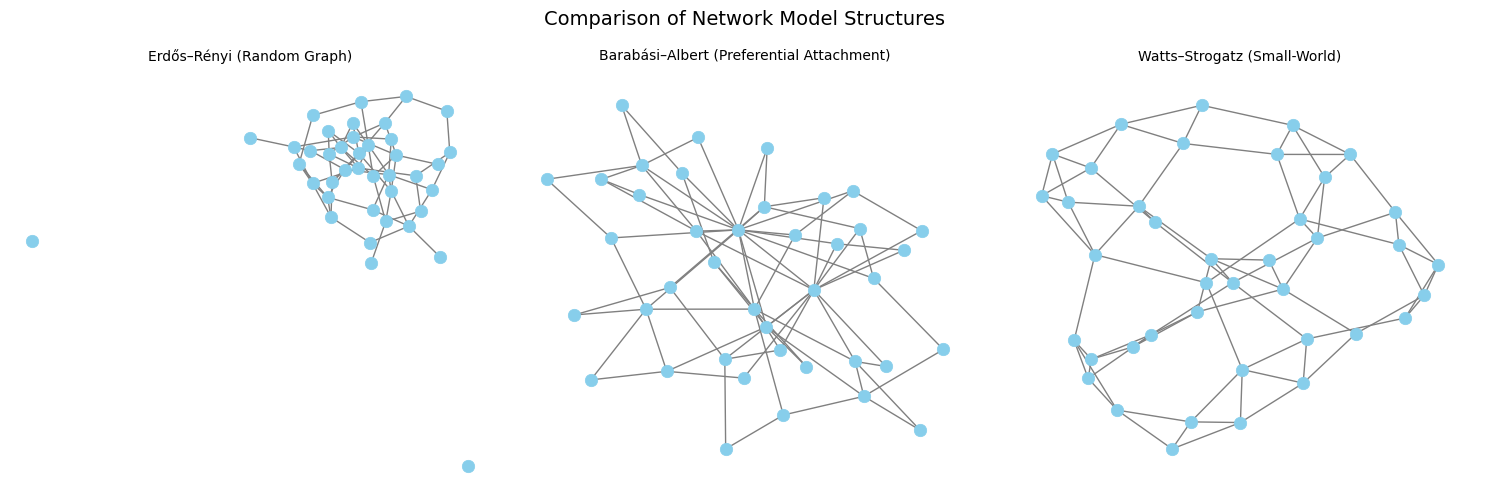

In [ ]:
# Visualize the three models side by side
ER_viz, BA_viz, WS_viz = model_graphs(n=40, p=0.08, m_attach=2, k=4, beta=0.2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
graphs = [('Erdős–Rényi (Random Graph)', ER_viz),
          ('Barabási–Albert (Preferential Attachment)', BA_viz),
          ('Watts–Strogatz (Small-World)', WS_viz)]

for ax, (title, Gv) in zip(axes, graphs):
    pos = nx.spring_layout(Gv, seed=0)
    nx.draw(Gv, pos,
            node_size=80,
            node_color='skyblue',
            edge_color='gray',
            linewidths=0.5,
            with_labels=False,
            ax=ax)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.suptitle("Comparison of Network Model Structures", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


# Part 4 — Edge Formation Mechanisms & Link Prediction Heuristics
We implement simple probability rules and heuristics:
- **Random Attachment**: constant probability
- **Preferential Attachment**: probability ∝ degree
- **Local Attachment**: common neighbors / Jaccard / Adamic–Adar
- **Homophily**: cosine similarity on node attributes


In [ ]:
from itertools import combinations
from math import log

def candidate_pairs(G):
    # Undirected candidate pairs that are not currently connected
    Gu = G.to_undirected()
    pairs = []
    for u, v in combinations(Gu.nodes(), 2):
        if not Gu.has_edge(u, v):
            pairs.append((u, v))
    return pairs

def preferential_attachment_scores(G):
    Gu = G.to_undirected()
    deg = dict(Gu.degree())
    scores = {}
    for u, v in candidate_pairs(G):
        scores[(u,v)] = deg[u] * deg[v]
    return scores

def common_neighbors_scores(G):
    Gu = G.to_undirected()
    scores = {}
    for u, v in candidate_pairs(G):
        cn = len(list(nx.common_neighbors(Gu, u, v)))
        scores[(u,v)] = cn
    return scores

def jaccard_scores(G):
    Gu = G.to_undirected()
    scores = {}
    for u, v in candidate_pairs(G):
        n_u = set(Gu.neighbors(u))
        n_v = set(Gu.neighbors(v))
        inter = len(n_u & n_v)
        uni = len(n_u | n_v)
        scores[(u,v)] = inter / uni if uni>0 else 0.0
    return scores

def adamic_adar_scores(G):
    Gu = G.to_undirected()
    scores = {}
    for u, v in candidate_pairs(G):
        cn = list(nx.common_neighbors(Gu, u, v))
        s = 0.0
        for w in cn:
            deg_w = Gu.degree(w)
            if deg_w > 1:
                s += 1.0 / log(deg_w)
        scores[(u,v)] = s
    return scores

def top_k(scores, k=5):
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]

# Demo on Karate graph
scores_pa = preferential_attachment_scores(K)
scores_cn = common_neighbors_scores(K)
scores_jc = jaccard_scores(K)
scores_aa = adamic_adar_scores(K)
pd.DataFrame({
    'PreferentialAttachment': dict(top_k(scores_pa, 10)),
    'CommonNeighbors': dict(top_k(scores_cn, 10)),
    'Jaccard': dict(top_k(scores_jc, 10)),
    'AdamicAdar': dict(top_k(scores_aa, 10))
})


PreferentialAttachment  CommonNeighbors  Jaccard  AdamicAdar
0  33                   272.0              4.0      NaN    2.711020
   32                   192.0              3.0      NaN    1.613740
2  33                   170.0              6.0      NaN    4.719381
1  33                   153.0              3.0      NaN    2.252922
   32                   108.0              NaN      NaN         NaN
3  33                   102.0              NaN      NaN         NaN
0  23                    80.0              NaN      NaN         NaN
3  32                    72.0              NaN      NaN         NaN
5  33                    68.0              NaN      NaN         NaN
6  33                    68.0              NaN      NaN         NaN
7  13                     NaN              4.0      NaN    1.808198
1  8                      NaN              3.0      NaN         NaN
2  30                     NaN              3.0      NaN         NaN
   31                     NaN              3.0      NaN    1.673343
4  5                      NaN              3.0      NaN    1.992261
6  10                     NaN              3.0      NaN    1.992261
14 15                     NaN              NaN      1.0         NaN
   18                     NaN              NaN      1.0         NaN
   20                     NaN              NaN      1.0         NaN
   22                     NaN              NaN      1.0         NaN
15 18                     NaN              NaN      1.0         NaN
   20                     NaN              NaN      1.0         NaN
   22                     NaN              NaN      1.0         NaN
17 21                     NaN              NaN      1.0         NaN
18 20                     NaN              NaN      1.0         NaN
   22                     NaN              NaN      1.0         NaN
23 31                     NaN              NaN      NaN    1.665625
   24                     NaN              NaN      NaN    1.631587

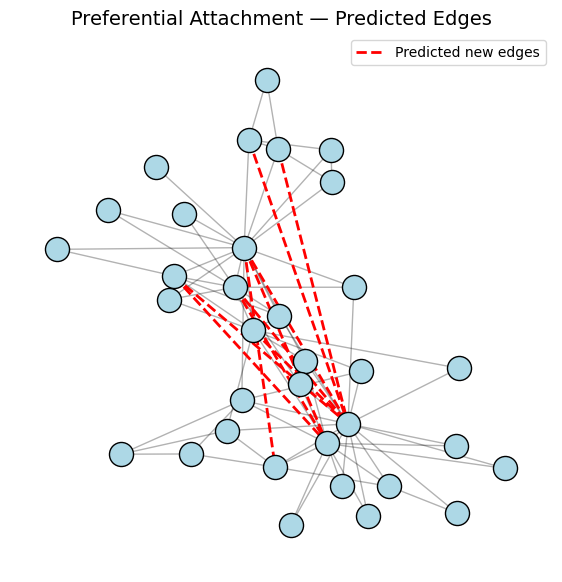

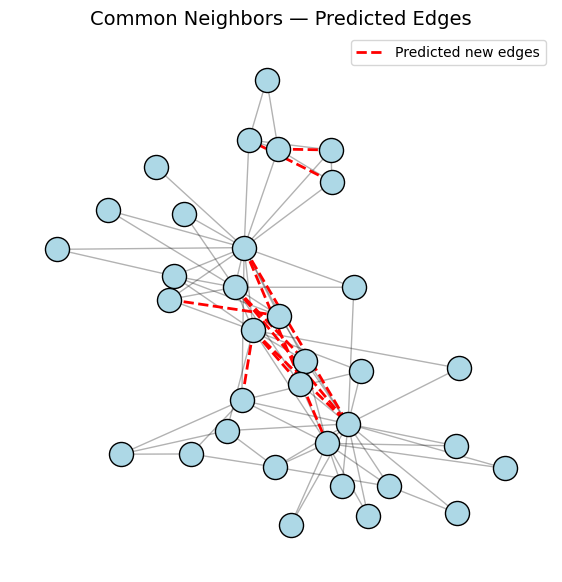

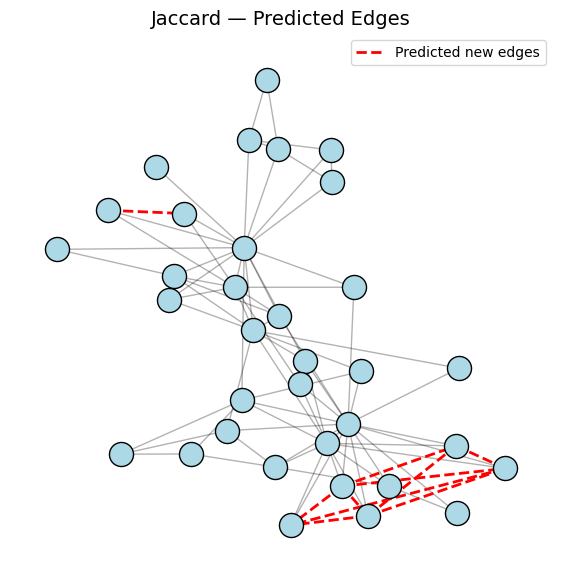

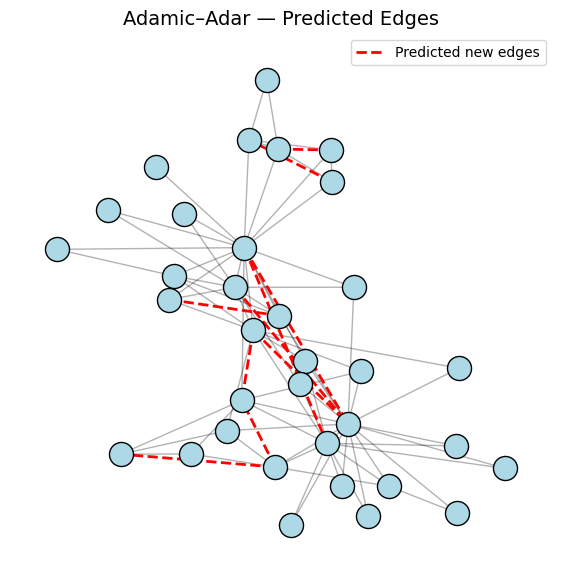

In [ ]:

def visualize_predicted_edges(G, score_dict, top_k=10, title="Predicted Edges"):
    """
    Visualize the top predicted new edges for a given scoring rule.
    
    Parameters:
        G (networkx.Graph): Base graph
        score_dict (dict): {(u,v): score} mapping
        top_k (int): number of top edges to highlight
        title (str): plot title
    """
    Gu = G.to_undirected()
    pos = nx.spring_layout(Gu, seed=0)
    
    # Take top k predicted edges
    top_edges = [pair for pair, _ in sorted(score_dict.items(), key=lambda x: x[1], reverse=True)[:top_k]]
    
    # Draw base network (existing edges)
    plt.figure(figsize=(7, 7))
    nx.draw_networkx_nodes(Gu, pos, node_size=300, node_color="lightblue", edgecolors="black")
    nx.draw_networkx_edges(Gu, pos, alpha=0.3)
    
    # Overlay predicted edges in red
    nx.draw_networkx_edges(Gu, pos, edgelist=top_edges, edge_color="red", width=2.0, style="dashed", label="Predicted new edges")
    
    plt.title(title, fontsize=14)
    plt.legend()
    plt.axis("off")
    plt.show()

# --- Example visualizations on the Karate Club graph ---
visualize_predicted_edges(K, scores_pa, top_k=10, title="Preferential Attachment — Predicted Edges")
visualize_predicted_edges(K, scores_cn, top_k=10, title="Common Neighbors — Predicted Edges")
visualize_predicted_edges(K, scores_jc, top_k=10, title="Jaccard — Predicted Edges")
visualize_predicted_edges(K, scores_aa, top_k=10, title="Adamic–Adar — Predicted Edges")

### Homophily (Attribute Similarity)
We simulate numeric attributes and use cosine similarity as a proxy for homophily.

In [ ]:
def random_attributes(G, d=4):
    X = {n: np.random.randn(d) for n in G.nodes()}
    return X

def cosine_similarity(u, v):
    num = np.dot(u, v)
    den = (np.linalg.norm(u) * np.linalg.norm(v))
    return float(num/den) if den>0 else 0.0

def homophily_scores(G, X):
    scores = {}
    for u, v in candidate_pairs(G):
        scores[(u,v)] = cosine_similarity(X[u], X[v])
    return scores

XK = random_attributes(K)
scores_h = homophily_scores(K, XK)
pd.Series(dict(top_k(scores_h, 10)))


27  32    0.958663
3   9     0.947123
4   15    0.919863
20  26    0.912968
4   23    0.896922
2   4     0.892641
7   33    0.888613
15  23    0.887981
10  24    0.881361
1   26    0.879961
dtype: float64

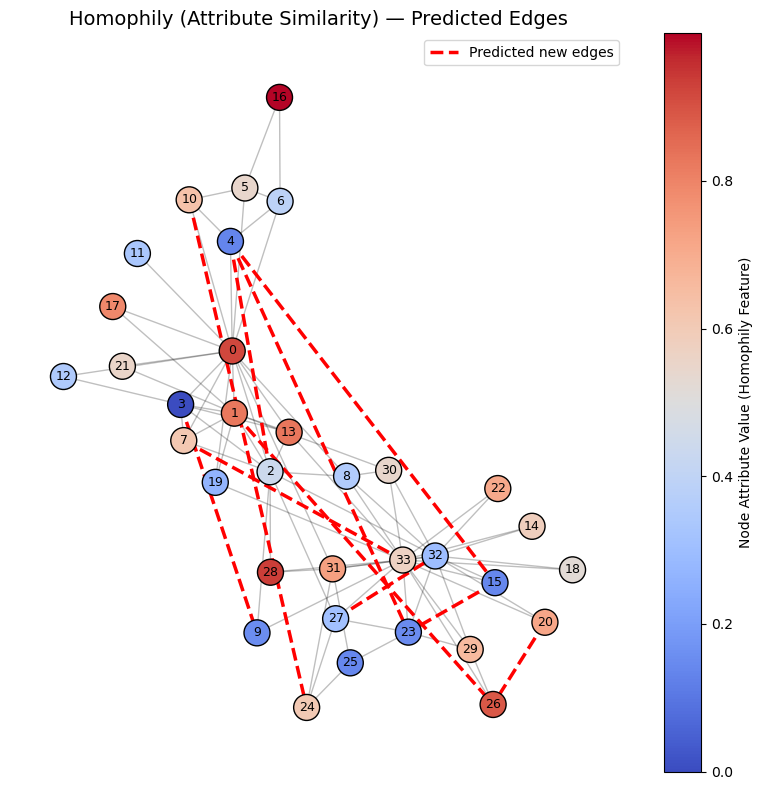

In [ ]:

def visualize_homophily(G, X, scores_h, top_k=10, title="Homophily (Attribute Similarity) — Predicted Edges"):
    """
    Visualize nodes colored by attribute values and top predicted edges by similarity.
    """
    Gu = G.to_undirected()
    pos = nx.spring_layout(Gu, seed=1)
    
    # Reduce attributes to scalar color values (mean embedding dimension)
    attr_scalar = {n: np.mean(X[n]) for n in Gu.nodes()}
    node_colors = np.array([attr_scalar[n] for n in Gu.nodes()])
    
    # Normalize colors to 0–1 for consistent colormap scaling
    norm = (node_colors - node_colors.min()) / (node_colors.max() - node_colors.min() + 1e-9)
    
    # Select top-K predicted edges
    top_edges = [pair for pair, _ in sorted(scores_h.items(), key=lambda x: x[1], reverse=True)[:top_k]]
    
    plt.figure(figsize=(8,8))
    nodes = nx.draw_networkx_nodes(
        Gu, pos,
        node_size=350,
        node_color=norm,
        cmap=plt.cm.coolwarm,
        edgecolors="black"
    )
    nx.draw_networkx_edges(Gu, pos, alpha=0.25)
    nx.draw_networkx_edges(
        Gu, pos, edgelist=top_edges,
        edge_color="red",
        width=2.5,
        style="dashed",
        label="Predicted new edges"
    )
    nx.draw_networkx_labels(Gu, pos, font_size=9, font_color="black")

    plt.colorbar(nodes, label="Node Attribute Value (Homophily Feature)")
    plt.title(title, fontsize=14)
    plt.legend()
    plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_homophily(K, XK, scores_h, top_k=10)


# Part 5 — Diffusion (SIR) Simulation
We implement a simple discrete-time SIR model and compare diffusion on ER, BA, and WS graphs.

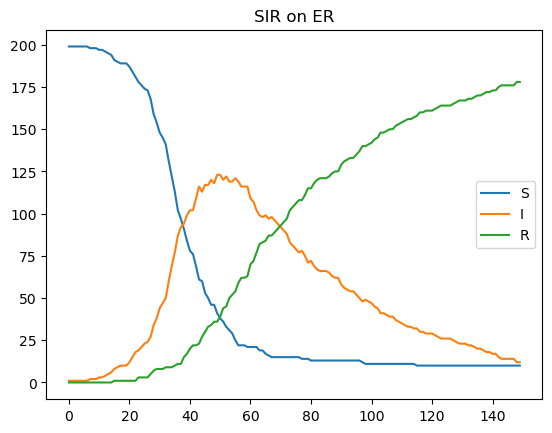

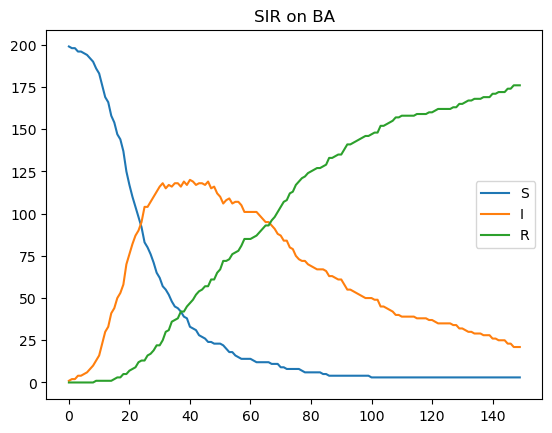

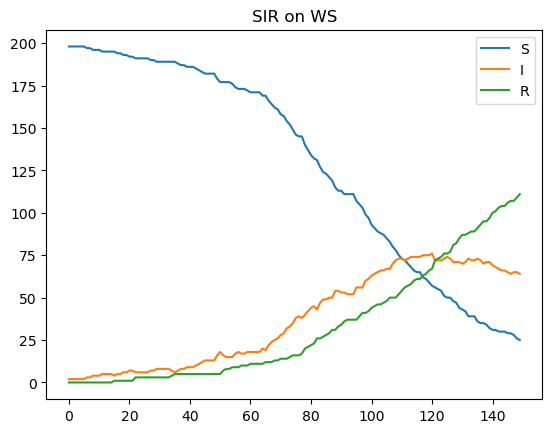

In [ ]:
def sir_simulation(G, beta=0.05, gamma=0.02, steps=100, seed_node=None):
    Gu = G.copy()
    nodes = list(Gu.nodes())
    if seed_node is None:
        seed_node = np.random.choice(nodes)
    state = {n: 'S' for n in nodes}
    state[seed_node] = 'I'
    S_hist, I_hist, R_hist = [], [], []
    for t in range(steps):
        new_state = state.copy()
        for n in nodes:
            if state[n] == 'I':
                # infect neighbors
                for nb in Gu.neighbors(n):
                    if state[nb] == 'S' and np.random.rand() < beta:
                        new_state[nb] = 'I'
                # recover
                if np.random.rand() < gamma:
                    new_state[n] = 'R'
        state = new_state
        S_hist.append(sum(1 for v in state.values() if v=='S'))
        I_hist.append(sum(1 for v in state.values() if v=='I'))
        R_hist.append(sum(1 for v in state.values() if v=='R'))
    return np.array(S_hist), np.array(I_hist), np.array(R_hist)

def compare_sir(n=200):
    ER, BA, WS = model_graphs(n=n, p=0.02, m_attach=2, k=4, beta=0.1)
    graphs = {'ER': ER, 'BA': BA, 'WS': WS}
    results = {}
    for name, g in graphs.items():
        S,I,R = sir_simulation(g, beta=0.05, gamma=0.02, steps=150)
        results[name] = (S,I,R)
    return results

results = compare_sir(n=200)
for name, (S,I,R) in results.items():
    plt.figure()
    plt.plot(S, label='S')
    plt.plot(I, label='I')
    plt.plot(R, label='R')
    plt.title(f'SIR on {name}')
    plt.legend()
    plt.show()


# Part 6 — Temporal SNA
Create a simple temporal network (edges appear over time) and track clustering & average degree.

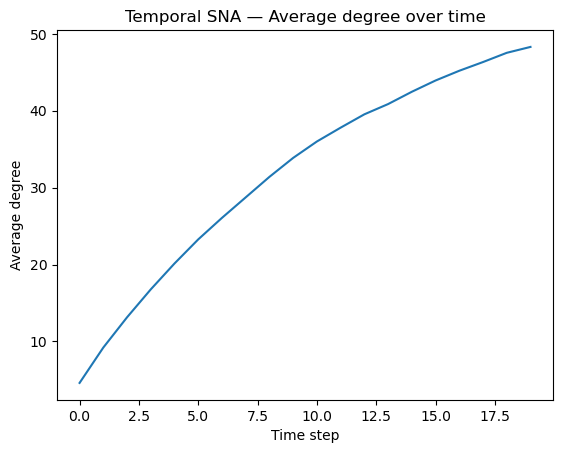

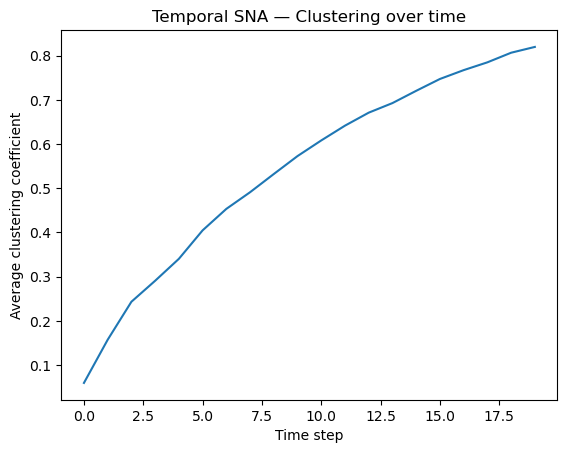

In [ ]:
def temporal_graph(n=60, T=20, prob_new_edge=0.08, seed=1):
    rng = np.random.default_rng(seed)
    base = nx.Graph()
    base.add_nodes_from(range(n))
    snapshots = []
    for t in range(T):
        Gu = base.copy()
        # randomly add some edges at each timestep
        for u in range(n):
            for v in range(u+1, n):
                if not Gu.has_edge(u,v) and rng.random() < prob_new_edge:
                    Gu.add_edge(u,v)
        snapshots.append(Gu)
        base = Gu
    return snapshots

snaps = temporal_graph()
ts = list(range(len(snaps)))
avg_deg = [np.mean([d for _,d in Gt.degree()]) for Gt in snaps]
avg_cc = [nx.average_clustering(Gt) if Gt.number_of_edges()>0 else 0.0 for Gt in snaps]

plt.figure()
plt.plot(ts, avg_deg)
plt.xlabel('Time step')
plt.ylabel('Average degree')
plt.title('Temporal SNA — Average degree over time')
plt.show()

plt.figure()
plt.plot(ts, avg_cc)
plt.xlabel('Time step')
plt.ylabel('Average clustering coefficient')
plt.title('Temporal SNA — Clustering over time')
plt.show()
